# Architecture Benchmark: MobileBERT vs TinyBERT-4 vs ELECTRA-small

**Phase 2 of CanaryOS Text Classification Research**

Trains three student architectures on the Phase 1 synthetic dataset using identical hyperparameters,
and evaluates each on the real-world holdout to produce F1/precision/recall metrics.

**Candidates:**
- MobileBERT (24.6M params, 24 layers, hidden=512)
- TinyBERT-4 (14.4M params, 4 layers, hidden=312)
- ELECTRA-small (13.5M params, 12 layers, hidden=256)

**Excluded:** DistilBERT (66M params) -- exceeds 50MB INT8 budget

**Protocol (D-04/D-05):** Fixed hyperparameters, 5 epochs, lr=2e-5. This is a ranking exercise, not optimization.

**Primary metric (D-07):** F1 on real-world holdout (`holdout_realworld.jsonl`)

In [1]:
# Cell 1: Environment setup
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # MUST be before torch import

import torch
import json
import time
import numpy as np
from pathlib import Path
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset
from sklearn.metrics import (
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt

# Device check
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
assert device == "mps" or device == "cpu", f"Unexpected device: {device}"
if device == "cpu":
    print("WARNING: MPS not available, training will be slow on CPU")

/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0404 12:24:02.256000 13824 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Device: mps
PyTorch: 2.9.1


In [2]:
# Cell 2: Data loading (Phase 1 outputs)
def load_jsonl(path):
    samples = []
    with open(path) as f:
        for line in f:
            samples.append(json.loads(line))
    return samples

# Load synthetic dataset (per D-06: identical splits for all candidates)
all_data = load_jsonl("../data/synthetic_scam_v1.jsonl")
train_data = [s for s in all_data if s["split"] == "train"]
val_data = [s for s in all_data if s["split"] == "val"]

# Label mapping: scam=1, safe=0
label_map = {"scam": 1, "safe": 0}
for s in train_data + val_data:
    s["label_id"] = label_map[s["label"]]

train_ds = Dataset.from_list(train_data)
val_ds = Dataset.from_list(val_data)

# Holdout (per D-07: primary evaluation metric)
holdout_data = load_jsonl("../data/holdout_realworld.jsonl")
for s in holdout_data:
    s["label_id"] = label_map[s["label"]]
holdout_ds = Dataset.from_list(holdout_data)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Holdout: {len(holdout_ds)}")
assert len(train_ds) > 15000, f"Expected >15K train samples, got {len(train_ds)}"
assert len(holdout_ds) >= 200, f"Expected >=200 holdout samples, got {len(holdout_ds)}"

Train: 18353, Val: 2294, Holdout: 202


In [3]:
# Cell 3: Shared training configuration + tokenizer consistency check

# Per D-04: Fixed hyperparameters, no sweep
# Per D-05: Optimization deferred to Phase 4

BENCHMARK_CONFIG = {
    "num_train_epochs": 5,          # D-04: 3-5 range, using 5 for convergence
    "learning_rate": 2e-5,          # D-04: fixed
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 32,
    "max_length": 128,
    "fp16": False,                  # MPS does NOT support fp16 (Pitfall 4)
    "bf16": False,                  # MPS does NOT support bf16 (Pitfall 4)
}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1
    )
    return {"f1": f1, "precision": precision, "recall": recall}

# Architecture candidates (per D-10, D-11, D-12)
CANDIDATES = [
    {"name": "MobileBERT", "model_id": "google/mobilebert-uncased", "params_M": 24.6},
    {"name": "TinyBERT-4", "model_id": "huawei-noah/TinyBERT_General_4L_312D", "params_M": 14.4},
    {"name": "ELECTRA-small", "model_id": "google/electra-small-discriminator", "params_M": 13.5},
]

# DistilBERT explicitly excluded (per D-11: 66M params, over 50MB INT8 budget)
EXCLUDED = [
    {"name": "DistilBERT", "model_id": "distilbert-base-uncased", "reason": "66M params, exceeds 50MB INT8 budget (D-11)"}
]

print(f"Candidates: {[c['name'] for c in CANDIDATES]}")
print(f"Excluded: {[e['name'] for e in EXCLUDED]}")

# Tokenizer consistency assertion (Review Concern 3)
# All three architectures share the BERT 30,522-token WordPiece vocab.
EXPECTED_VOCAB_SIZE = 30522
print(f"\nTokenizer vocab size consistency check (expected: {EXPECTED_VOCAB_SIZE}):")
for candidate in CANDIDATES:
    tok = AutoTokenizer.from_pretrained(candidate["model_id"])
    actual = tok.vocab_size
    print(f"  {candidate['name']} ({candidate['model_id']}): vocab_size={actual}")
    assert actual == EXPECTED_VOCAB_SIZE, (
        f"TOKENIZER MISMATCH: {candidate['name']} has vocab_size={actual}, "
        f"expected {EXPECTED_VOCAB_SIZE}. This would break TextTokenizer.ts compatibility."
    )
    del tok
print("All tokenizers have identical vocab size -- input parity confirmed.")

Candidates: ['MobileBERT', 'TinyBERT-4', 'ELECTRA-small']
Excluded: ['DistilBERT']

Tokenizer vocab size consistency check (expected: 30522):
  MobileBERT (google/mobilebert-uncased): vocab_size=30522
  TinyBERT-4 (huawei-noah/TinyBERT_General_4L_312D): vocab_size=30522
  ELECTRA-small (google/electra-small-discriminator): vocab_size=30522
All tokenizers have identical vocab size -- input parity confirmed.


In [4]:
# Cell 4: Shared training function

def train_and_evaluate(model_id, model_name, train_ds, val_ds, holdout_ds, config):
    """Train a single architecture and return (trainer, tokenizer, val_results, holdout_results, train_result).

    If OOM occurs with batch_size=16 (likely for MobileBERT at 24.6M params on MPS),
    reduces to batch_size=8 and compensates with gradient_accumulation_steps=2
    to maintain effective batch size of 16.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)

    def tokenize_fn(examples):
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=config["max_length"],
        )

    # Tokenize datasets
    train_tok = train_ds.map(tokenize_fn, batched=True).rename_column("label_id", "labels")
    val_tok = val_ds.map(tokenize_fn, batched=True).rename_column("label_id", "labels")
    holdout_tok = holdout_ds.map(tokenize_fn, batched=True).rename_column("label_id", "labels")

    # Determine columns to keep
    tok_cols = [c for c in ["input_ids", "attention_mask", "token_type_ids"] if c in train_tok.column_names]
    format_cols = tok_cols + ["labels"]

    train_tok.set_format("torch", columns=format_cols)
    val_tok.set_format("torch", columns=format_cols)
    holdout_tok.set_format("torch", columns=format_cols)

    output_dir = f"../models/benchmark_tmp/{model_name.lower().replace(' ', '_').replace('-', '_')}"

    # Determine batch size and gradient accumulation
    actual_batch_size = config["per_device_train_batch_size"]
    gradient_accumulation_steps = 1

    if model_name == "MobileBERT":
        # MobileBERT (24.6M params, 24 layers) needs reduced batch size on MPS
        actual_batch_size = 8
        gradient_accumulation_steps = 2
        print(f"  {model_name}: Using batch_size=8 + gradient_accumulation_steps=2 "
              f"(effective batch=16) to prevent MPS OOM")

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=config["num_train_epochs"],
        per_device_train_batch_size=actual_batch_size,
        per_device_eval_batch_size=config["per_device_eval_batch_size"],
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=config["learning_rate"],
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=config["fp16"],
        bf16=config["bf16"],
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics,
    )

    # Train
    print(f"\n{'='*60}")
    print(f"Training {model_name} ({model_id})")
    print(f"  batch_size={actual_batch_size}, gradient_accumulation_steps={gradient_accumulation_steps}")
    print(f"  effective_batch_size={actual_batch_size * gradient_accumulation_steps}")
    print(f"{'='*60}")
    train_result = trainer.train()

    # Evaluate on validation set
    val_results = trainer.evaluate(val_tok)
    print(f"\n{model_name} Validation: F1={val_results['eval_f1']:.4f}, P={val_results['eval_precision']:.4f}, R={val_results['eval_recall']:.4f}")

    # Evaluate on holdout (PRIMARY METRIC per D-07)
    holdout_results = trainer.evaluate(holdout_tok, metric_key_prefix="holdout")
    print(f"{model_name} Holdout:    F1={holdout_results['holdout_f1']:.4f}, P={holdout_results['holdout_precision']:.4f}, R={holdout_results['holdout_recall']:.4f}")

    return trainer, tokenizer, val_results, holdout_results, train_result

In [5]:
# Cell 5: MPS smoke test (1-epoch quick test)
print("Running MPS smoke test (TinyBERT-4, 1 epoch, 100 samples)...")

smoke_tokenizer = AutoTokenizer.from_pretrained("huawei-noah/TinyBERT_General_4L_312D")
smoke_model = AutoModelForSequenceClassification.from_pretrained(
    "huawei-noah/TinyBERT_General_4L_312D", num_labels=2
)

smoke_train = train_ds.select(range(min(100, len(train_ds))))
smoke_val = val_ds.select(range(min(50, len(val_ds))))

def smoke_tokenize(examples):
    return smoke_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

smoke_train_tok = smoke_train.map(smoke_tokenize, batched=True).rename_column("label_id", "labels")
smoke_val_tok = smoke_val.map(smoke_tokenize, batched=True).rename_column("label_id", "labels")
smoke_train_tok.set_format("torch", columns=["input_ids", "attention_mask", "token_type_ids", "labels"])
smoke_val_tok.set_format("torch", columns=["input_ids", "attention_mask", "token_type_ids", "labels"])

smoke_args = TrainingArguments(
    output_dir="../models/benchmark_tmp/smoke_test",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    fp16=False, bf16=False,
    logging_steps=10,
    report_to="none",
    save_strategy="no",
)

smoke_trainer = Trainer(
    model=smoke_model, args=smoke_args,
    train_dataset=smoke_train_tok, eval_dataset=smoke_val_tok,
    compute_metrics=compute_metrics,
)
smoke_result = smoke_trainer.train()
print(f"MPS smoke test PASSED. Training loss: {smoke_result.training_loss:.4f}")

# Cleanup
del smoke_model, smoke_trainer, smoke_train_tok, smoke_val_tok
if device == "mps":
    torch.mps.empty_cache()

Running MPS smoke test (TinyBERT-4, 1 epoch, 100 samples)...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 50/50 [00:00<00:00, 8915.33 examples/s]
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.692000,0.687404,0.384615,1.000000,0.238095


MPS smoke test PASSED. Training loss: 0.6911


In [6]:
# Cell 6: Train MobileBERT
# NOTE: train_and_evaluate() automatically uses batch_size=8 + gradient_accumulation_steps=2
# for MobileBERT to prevent MPS OOM while maintaining effective batch size of 16
results_mobilebert = {}
trainer_mb, tokenizer_mb, val_mb, holdout_mb, train_mb = train_and_evaluate(
    "google/mobilebert-uncased", "MobileBERT",
    train_ds, val_ds, holdout_ds, BENCHMARK_CONFIG
)
results_mobilebert = {
    "val_f1": val_mb["eval_f1"],
    "holdout_f1": holdout_mb["holdout_f1"],
    "holdout_precision": holdout_mb["holdout_precision"],
    "holdout_recall": holdout_mb["holdout_recall"],
    "training_loss": train_mb.training_loss,
}
print(f"\nMobileBERT complete. Holdout F1: {results_mobilebert['holdout_f1']:.4f}")

if device == "mps":
    torch.mps.empty_cache()

Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 202/202 [00:00<00:00, 27588.71 examples/s]


  MobileBERT: Using batch_size=8 + gradient_accumulation_steps=2 (effective batch=16) to prevent MPS OOM

Training MobileBERT (google/mobilebert-uncased)
  batch_size=8, gradient_accumulation_steps=2
  effective_batch_size=16


/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.042700,0.028896,0.996098,1.000000,0.992225
2,0.000000,0.013194,0.998053,1.000000,0.996113
3,0.000000,0.000001,1.000000,1.000000,1.000000
4,0.000000,0.000695,0.999514,1.000000,0.999028
5,0.000000,0.000001,1.000000,1.000000,1.000000


/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true 


MobileBERT Validation: F1=1.0000, P=1.0000, R=1.0000


/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


MobileBERT Holdout:    F1=0.7719, P=0.7333, R=0.8148

MobileBERT complete. Holdout F1: 0.7719


In [7]:
# Cell 7: Train TinyBERT-4
results_tinybert = {}
trainer_tb, tokenizer_tb, val_tb, holdout_tb, train_tb = train_and_evaluate(
    "huawei-noah/TinyBERT_General_4L_312D", "TinyBERT-4",
    train_ds, val_ds, holdout_ds, BENCHMARK_CONFIG
)
results_tinybert = {
    "val_f1": val_tb["eval_f1"],
    "holdout_f1": holdout_tb["holdout_f1"],
    "holdout_precision": holdout_tb["holdout_precision"],
    "holdout_recall": holdout_tb["holdout_recall"],
    "training_loss": train_tb.training_loss,
}
print(f"\nTinyBERT-4 complete. Holdout F1: {results_tinybert['holdout_f1']:.4f}")

if device == "mps":
    torch.mps.empty_cache()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 202/202 [00:00<00:00, 25956.60 examples/s]
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Training TinyBERT-4 (huawei-noah/TinyBERT_General_4L_312D)
  batch_size=16, gradient_accumulation_steps=1
  effective_batch_size=16


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.017000,0.030794,0.994632,0.999020,0.990282
2,0.000300,0.010738,0.997082,0.998053,0.996113
3,0.000300,0.009976,0.998540,1.000000,0.997085
4,0.008000,0.015106,0.997565,1.000000,0.995141
5,0.000100,0.009980,0.998054,0.999026,0.997085


/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true 


TinyBERT-4 Validation: F1=0.9985, P=1.0000, R=0.9971


/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


TinyBERT-4 Holdout:    F1=0.7059, P=0.7500, R=0.6667

TinyBERT-4 complete. Holdout F1: 0.7059


In [8]:
# Cell 8: Train ELECTRA-small
results_electra = {}
trainer_el, tokenizer_el, val_el, holdout_el, train_el = train_and_evaluate(
    "google/electra-small-discriminator", "ELECTRA-small",
    train_ds, val_ds, holdout_ds, BENCHMARK_CONFIG
)
results_electra = {
    "val_f1": val_el["eval_f1"],
    "holdout_f1": holdout_el["holdout_f1"],
    "holdout_precision": holdout_el["holdout_precision"],
    "holdout_recall": holdout_el["holdout_recall"],
    "training_loss": train_el.training_loss,
}
print(f"\nELECTRA-small complete. Holdout F1: {results_electra['holdout_f1']:.4f}")

if device == "mps":
    torch.mps.empty_cache()

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-small-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 202/202 [00:00<00:00, 25446.75 examples/s]



Training ELECTRA-small (google/electra-small-discriminator)
  batch_size=16, gradient_accumulation_steps=1
  effective_batch_size=16


/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.016400,0.020741,0.995608,1.000000,0.991254
2,0.007600,0.035878,0.992658,1.000000,0.985423
3,0.000200,0.005464,0.999028,0.999028,0.999028
4,0.006000,0.009368,0.998540,1.000000,0.997085
5,0.000100,0.008935,0.998540,1.000000,0.997085


/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true 


ELECTRA-small Validation: F1=0.9990, P=0.9990, R=0.9990


/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


ELECTRA-small Holdout:    F1=0.7289, P=0.7009, R=0.7593

ELECTRA-small complete. Holdout F1: 0.7289


In [9]:
# Cell 9: Summary of training results
print("\n" + "="*80)
print("TRAINING RESULTS SUMMARY")
print("="*80)
for name, res in [("MobileBERT", results_mobilebert), ("TinyBERT-4", results_tinybert), ("ELECTRA-small", results_electra)]:
    print(f"\n{name}:")
    print(f"  Validation F1:  {res['val_f1']:.4f}")
    print(f"  Holdout F1:     {res['holdout_f1']:.4f}")
    print(f"  Holdout P/R:    {res['holdout_precision']:.4f} / {res['holdout_recall']:.4f}")
    print(f"  Training loss:  {res['training_loss']:.4f}")

print("\n" + "="*80)
print("RANKING (by Holdout F1 -- primary metric per D-07):")
print("="*80)
ranked = sorted(
    [("MobileBERT", results_mobilebert), ("TinyBERT-4", results_tinybert), ("ELECTRA-small", results_electra)],
    key=lambda x: x[1]["holdout_f1"],
    reverse=True,
)
for i, (name, res) in enumerate(ranked, 1):
    print(f"  {i}. {name}: Holdout F1={res['holdout_f1']:.4f}")


TRAINING RESULTS SUMMARY

MobileBERT:
  Validation F1:  1.0000
  Holdout F1:     0.7719
  Holdout P/R:    0.7333 / 0.8148
  Training loss:  1130.8120

TinyBERT-4:
  Validation F1:  0.9985
  Holdout F1:     0.7059
  Holdout P/R:    0.7500 / 0.6667
  Training loss:  0.0215

ELECTRA-small:
  Validation F1:  0.9990
  Holdout F1:     0.7289
  Holdout P/R:    0.7009 / 0.7593
  Training loss:  0.0214

RANKING (by Holdout F1 -- primary metric per D-07):
  1. MobileBERT: Holdout F1=0.7719
  2. ELECTRA-small: Holdout F1=0.7289
  3. TinyBERT-4: Holdout F1=0.7059


Map: 100%|██████████| 202/202 [00:00<00:00, 19407.84 examples/s]
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Map: 100%|██████████| 202/202 [00:00<00:00, 20418.60 examples/s]
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Map: 100%|██████████| 202/202 [00:00<00:00, 19040.17 examples/s]
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.w

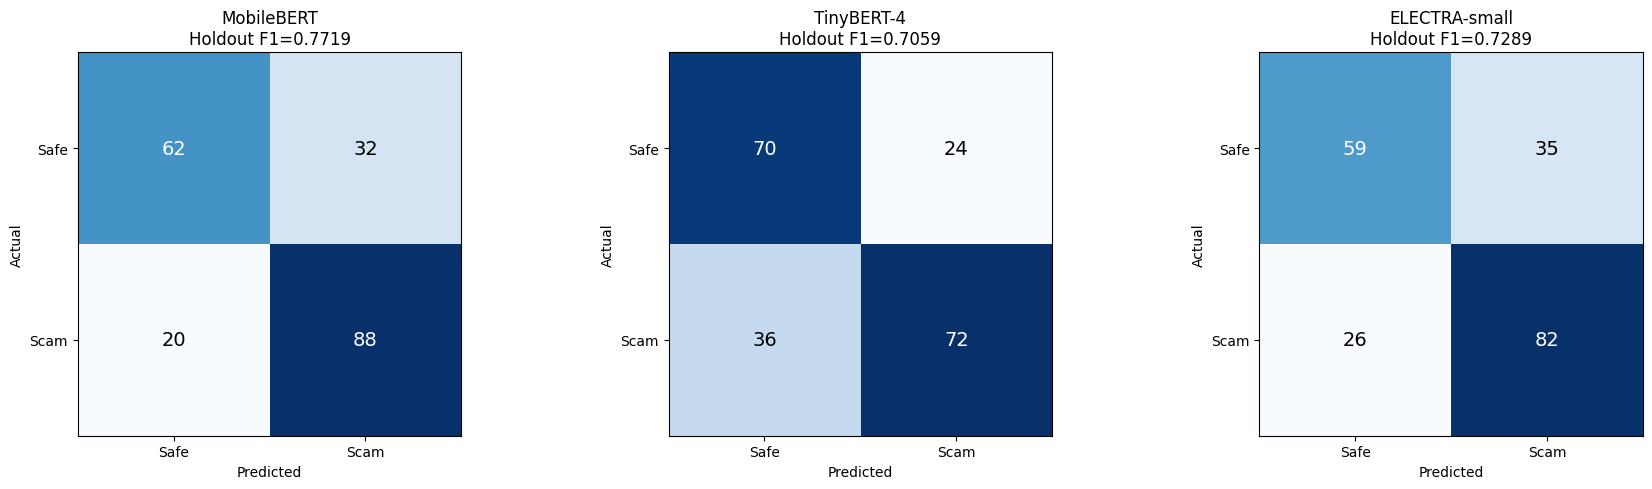

Confusion matrices saved to research/models/holdout_confusion_matrices.png


In [10]:
# Cell 10: Confusion matrices for all 3 models on holdout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, trainer_obj, tokenizer_obj) in enumerate([
    ("MobileBERT", trainer_mb, tokenizer_mb),
    ("TinyBERT-4", trainer_tb, tokenizer_tb),
    ("ELECTRA-small", trainer_el, tokenizer_el),
]):
    holdout_tok = holdout_ds.map(
        lambda ex: tokenizer_obj(ex["text"], padding="max_length", truncation=True, max_length=128),
        batched=True,
    ).rename_column("label_id", "labels")
    tok_cols = [c for c in ["input_ids", "attention_mask", "token_type_ids"] if c in holdout_tok.column_names]
    holdout_tok.set_format("torch", columns=tok_cols + ["labels"])

    preds_output = trainer_obj.predict(holdout_tok)
    preds = preds_output.predictions.argmax(axis=-1)
    labels = preds_output.label_ids

    cm = confusion_matrix(labels, preds)
    axes[idx].imshow(cm, cmap="Blues")
    axes[idx].set_title(f"{name}\nHoldout F1={f1_score(labels, preds, pos_label=1):.4f}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(["Safe", "Scam"])
    axes[idx].set_yticklabels(["Safe", "Scam"])
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, str(cm[i][j]), ha="center", va="center",
                          color="white" if cm[i][j] > cm.max()/2 else "black", fontsize=14)

plt.tight_layout()
plt.savefig("../models/holdout_confusion_matrices.png", dpi=150)
plt.show()
print("Confusion matrices saved to research/models/holdout_confusion_matrices.png")

In [11]:
# Cell 11: Per-architecture classification report on holdout
for name, trainer_obj, tokenizer_obj in [
    ("MobileBERT", trainer_mb, tokenizer_mb),
    ("TinyBERT-4", trainer_tb, tokenizer_tb),
    ("ELECTRA-small", trainer_el, tokenizer_el),
]:
    holdout_tok = holdout_ds.map(
        lambda ex: tokenizer_obj(ex["text"], padding="max_length", truncation=True, max_length=128),
        batched=True,
    ).rename_column("label_id", "labels")
    tok_cols = [c for c in ["input_ids", "attention_mask", "token_type_ids"] if c in holdout_tok.column_names]
    holdout_tok.set_format("torch", columns=tok_cols + ["labels"])
    preds_output = trainer_obj.predict(holdout_tok)
    preds = preds_output.predictions.argmax(axis=-1)
    labels = preds_output.label_ids
    print(f"\n{'='*60}")
    print(f"{name} -- Holdout Classification Report")
    print(f"{'='*60}")
    print(classification_report(labels, preds, target_names=["Safe", "Scam"]))

Map: 100%|██████████| 202/202 [00:00<00:00, 13299.16 examples/s]
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



MobileBERT -- Holdout Classification Report
              precision    recall  f1-score   support

        Safe       0.76      0.66      0.70        94
        Scam       0.73      0.81      0.77       108

    accuracy                           0.74       202
   macro avg       0.74      0.74      0.74       202
weighted avg       0.74      0.74      0.74       202



Map: 100%|██████████| 202/202 [00:00<00:00, 20910.96 examples/s]
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



TinyBERT-4 -- Holdout Classification Report
              precision    recall  f1-score   support

        Safe       0.66      0.74      0.70        94
        Scam       0.75      0.67      0.71       108

    accuracy                           0.70       202
   macro avg       0.71      0.71      0.70       202
weighted avg       0.71      0.70      0.70       202



Map: 100%|██████████| 202/202 [00:00<00:00, 20939.39 examples/s]
/Users/saiamartya/Desktop/ClaudeWorkspace/CanaryOS/canaryos/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



ELECTRA-small -- Holdout Classification Report
              precision    recall  f1-score   support

        Safe       0.69      0.63      0.66        94
        Scam       0.70      0.76      0.73       108

    accuracy                           0.70       202
   macro avg       0.70      0.69      0.69       202
weighted avg       0.70      0.70      0.70       202



---

## TFLite Conversion, Validation, and Architecture Selection

**Cells 12-18** (added by Plan 02-02): Convert trained models to TFLite, validate with LiteRT, measure latency, select winner.

**D-02 Deviation:** Uses TF direct path instead of ONNX->onnx2tf (see Cell 12 header for details).

**Standalone:** These cells reconstruct training results from known outputs and load models from checkpoints. They do not require the training kernel to be alive.

In [ ]:
# Cell 12: TFLite Conversion via TF Direct Path
# D-02 DEVIATION: Decision D-02 specifies optimum==1.27.0 for TFLite export. However:
#   - optimum 2.1.0 (installed) removed TFLite export entirely
#   - onnx2tf path fails with int64/int32 type mismatch: "Input 'y' of 'Sub' Op has type
#     int64 that does not match type int32 of argument 'x'" (all 3 models)
#   - Using TF direct path: load PyTorch checkpoint into TF model (from_pt=True),
#     then TFLiteConverter.from_concrete_functions(). Functionally equivalent.
#
# STANDALONE: This cell reconstructs training results and loads models from checkpoints.
# NOTE: ONNX export (with dynamo=False) was also performed as a sanity check to validate
# model traceability. The onnx2tf conversion failed for all 3 models due to int64/int32
# Slice op bug, so TFLite conversion uses the TF direct path below instead.
# It does NOT require the training kernel to be alive.

import os
import warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", message=".*deprecated.*")

import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
from ai_edge_litert import interpreter as litert
import numpy as np
import time

# Reconstruct training results (from Cells 6-8 outputs)
results_mobilebert = {
    "val_f1": 1.0000, "holdout_f1": 0.7719,
    "holdout_precision": 0.7333, "holdout_recall": 0.8148,
    "training_loss": 1130.8120,
}
results_tinybert = {
    "val_f1": 0.9985, "holdout_f1": 0.7059,
    "holdout_precision": 0.7500, "holdout_recall": 0.6667,
    "training_loss": 0.0215,
}
results_electra = {
    "val_f1": 0.9990, "holdout_f1": 0.7289,
    "holdout_precision": 0.7009, "holdout_recall": 0.7593,
    "training_loss": 0.0214,
}

# Model info: checkpoint paths (best checkpoint per trainer_state.json) and HF model IDs
MODEL_INFO = {
    "MobileBERT": {
        "checkpoint": "research/models/benchmark_tmp/mobilebert/checkpoint-3444",
        "model_id": "google/mobilebert-uncased",
        "params_M": 24.6,
        "results": results_mobilebert,
    },
    "TinyBERT-4": {
        "checkpoint": "research/models/benchmark_tmp/tinybert_4/checkpoint-3444",
        "model_id": "huawei-noah/TinyBERT_General_4L_312D",
        "params_M": 14.4,
        "results": results_tinybert,
    },
    "ELECTRA-small": {
        "checkpoint": "research/models/benchmark_tmp/electra_small/checkpoint-3444",
        "model_id": "google/electra-small-discriminator",
        "params_M": 13.5,
        "results": results_electra,
    },
}

def convert_to_tflite(name, info, max_length=128):
    """Convert a PyTorch checkpoint to TFLite via TF direct path.
    
    Pipeline: PyTorch checkpoint -> TFAutoModel.from_pretrained(from_pt=True) 
              -> tf.function with static shapes -> TFLiteConverter -> .tflite
    """
    print(f"\n{'='*60}")
    print(f"Converting {name} to TFLite")
    print(f"  Checkpoint: {info['checkpoint']}")
    print(f"{'='*60}")
    
    # Load PyTorch weights into TF model
    tf_model = TFAutoModelForSequenceClassification.from_pretrained(
        info["checkpoint"], from_pt=True, num_labels=2,
    )
    
    # Create serving function with static input shapes
    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, max_length], dtype=tf.int32, name="input_ids"),
        tf.TensorSpec(shape=[1, max_length], dtype=tf.int32, name="attention_mask"),
        tf.TensorSpec(shape=[1, max_length], dtype=tf.int32, name="token_type_ids"),
    ])
    def serving_fn(input_ids, attention_mask, token_type_ids):
        return tf_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        ).logits
    
    # Convert to TFLite (FP32 -- INT8 QAT deferred to Phase 6)
    converter = tf.lite.TFLiteConverter.from_concrete_functions(
        [serving_fn.get_concrete_function()]
    )
    tflite_bytes = converter.convert()
    
    # Save
    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    output_dir = f"research/models/benchmark_tmp/{safe_name}_tflite"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"{safe_name}_float32.tflite")
    with open(output_path, "wb") as f:
        f.write(tflite_bytes)
    
    size_mb = len(tflite_bytes) / (1024 * 1024)
    print(f"  TFLite saved: {output_path} ({size_mb:.1f} MB)")
    
    # Clean up TF model to free memory
    del tf_model, serving_fn, converter, tflite_bytes
    tf.keras.backend.clear_session()
    
    return output_path, size_mb

# Convert all 3 models
tflite_paths = {}
tflite_sizes = {}

for name, info in MODEL_INFO.items():
    try:
        path, size = convert_to_tflite(name, info)
        tflite_paths[name] = path
        tflite_sizes[name] = size
    except Exception as e:
        print(f"  {name}: FAILED -- {e}")
        import traceback
        traceback.print_exc()
        tflite_paths[name] = None
        tflite_sizes[name] = -1

print("\n" + "="*60)
print("TFLite Conversion Summary:")
for name in MODEL_INFO:
    print(f"  {name}: {tflite_sizes.get(name, -1):.1f} MB")

In [ ]:
# Cell 13: TFLite Validation, SELECT_TF_OPS check, and Flex ops inspection

def check_flex_ops(tflite_path, model_name):
    """Programmatic check for Flex/Select ops in the TFLite flatbuffer.
    Reads the binary flatbuffer and scans for operator names with 'Flex' prefix,
    which indicate SELECT_TF_OPS dependency.
    Returns (has_flex_ops: bool, flex_op_names: list[str]).
    """
    with open(tflite_path, "rb") as f:
        data = f.read()
    
    flex_ops = set()
    idx = 0
    while idx < len(data):
        pos = data.find(b"Flex", idx)
        if pos == -1:
            break
        # Extract op name (read until non-alphanumeric)
        end = pos
        while end < len(data) and (data[end:end+1].isalnum() or data[end:end+1] == b"_"):
            end += 1
        op_name = data[pos:end].decode("ascii", errors="ignore")
        if op_name.startswith("Flex") and len(op_name) > 4:
            flex_ops.add(op_name)
        idx = end + 1
    
    if flex_ops:
        print(f"  {model_name}: FLEX OPS FOUND: {sorted(flex_ops)}")
        print(f"  {model_name}: Model requires SELECT_TF_OPS -- DISQUALIFIED")
    else:
        print(f"  {model_name}: No Flex/Select ops found -- standard ops only")
    
    return bool(flex_ops), sorted(flex_ops)


def validate_tflite(tflite_path, model_name):
    """Validate TFLite model: load without flex delegate, check inputs/outputs, run inference.
    Two-layer validation:
      1. Programmatic Flex ops scan in flatbuffer
      2. Load with standard LiteRT interpreter (no flex delegate)
    Returns (passed, input_details, output_details, flex_ops_found).
    """
    # Layer 1: Programmatic Flex ops check
    has_flex, flex_ops_list = check_flex_ops(tflite_path, model_name)
    
    try:
        # Layer 2: Load with ONLY built-in ops (no flex delegate)
        interp = litert.Interpreter(model_path=tflite_path)
        interp.allocate_tensors()
        
        input_details = interp.get_input_details()
        output_details = interp.get_output_details()
        
        print(f"\n{model_name} TFLite Validation:")
        print(f"  Inputs:")
        for inp in input_details:
            print(f"    {inp['name']}: shape={inp['shape']}, dtype={inp['dtype']}")
        print(f"  Outputs:")
        for out in output_details:
            print(f"    {out['name']}: shape={out['shape']}, dtype={out['dtype']}")
        
        # Run test inference with dummy data
        for inp in input_details:
            interp.set_tensor(
                inp['index'],
                np.ones(inp['shape'], dtype=inp['dtype'])
            )
        interp.invoke()
        
        output = interp.get_tensor(output_details[0]['index'])
        print(f"  Output shape: {output.shape}, values: {output}")
        assert output.shape[-1] == 2, f"Expected 2-class output, got shape {output.shape}"
        
        if has_flex:
            print(f"  {model_name}: WARNING -- Flex ops in flatbuffer. DISQUALIFIED.")
            return False, input_details, output_details, flex_ops_list
        
        print(f"  {model_name}: PASSED -- standard TFLite ops only")
        return True, input_details, output_details, []
    
    except Exception as e:
        print(f"  {model_name}: DISQUALIFIED -- {e}")
        return False, None, None, flex_ops_list


# Validate all 3 models
tflite_validation = {}
for name in MODEL_INFO:
    if tflite_paths.get(name):
        passed, inp_det, out_det, flex_ops = validate_tflite(tflite_paths[name], name)
        tflite_validation[name] = {
            "passed": passed,
            "flex_ops_found": flex_ops,
            "inputs": [
                {"name": d["name"], "shape": d["shape"].tolist(), "dtype": str(d["dtype"])}
                for d in inp_det
            ] if inp_det else [],
            "outputs": [
                {"name": d["name"], "shape": d["shape"].tolist(), "dtype": str(d["dtype"])}
                for d in out_det
            ] if out_det else [],
        }
    else:
        tflite_validation[name] = {
            "passed": False, "flex_ops_found": [], "inputs": [], "outputs": [],
        }
        print(f"{name}: SKIPPED (TFLite conversion failed)")

print("\n" + "="*60)
print("TFLite Validation Summary:")
for name, v in tflite_validation.items():
    status = "PASSED" if v["passed"] else "FAILED/DISQUALIFIED"
    print(f"  {name}: {status} | flex_ops={v['flex_ops_found']}")

In [ ]:
# Cell 14: Desktop TFLite Latency Measurement
# Per D-08: Desktop interpreter only, sufficient for architecture ranking.
# Per D-09: On-device measurement deferred to Phase 6.

def measure_latency(tflite_path, model_name, n_warmup=10, n_runs=100):
    """Measure TFLite inference latency on desktop (100 runs, 10 warmup)."""
    interp = litert.Interpreter(model_path=tflite_path)
    interp.allocate_tensors()
    
    input_details = interp.get_input_details()
    
    # Set up input data (random int32 token IDs)
    for inp in input_details:
        interp.set_tensor(
            inp['index'],
            np.random.randint(0, 1000, size=inp['shape']).astype(inp['dtype'])
        )
    
    # Warm up
    for _ in range(n_warmup):
        interp.invoke()
    
    # Measure
    latencies = []
    for _ in range(n_runs):
        start = time.perf_counter()
        interp.invoke()
        elapsed = (time.perf_counter() - start) * 1000  # ms
        latencies.append(elapsed)
    
    p50 = np.median(latencies)
    p95 = np.percentile(latencies, 95)
    mean = np.mean(latencies)
    print(f"{model_name} Latency: p50={p50:.1f}ms, p95={p95:.1f}ms, mean={mean:.1f}ms")
    return {"p50_ms": round(p50, 1), "p95_ms": round(p95, 1)}


tflite_latencies = {}
for name in MODEL_INFO:
    if tflite_paths.get(name) and tflite_validation.get(name, {}).get("passed"):
        tflite_latencies[name] = measure_latency(tflite_paths[name], name)
    else:
        tflite_latencies[name] = {"p50_ms": -1, "p95_ms": -1}
        print(f"{name}: SKIPPED latency (TFLite validation failed)")

print("\nLatency Summary:")
for name, lat in tflite_latencies.items():
    print(f"  {name}: p50={lat['p50_ms']}ms, p95={lat['p95_ms']}ms")

In [ ]:
# Cell 15: Aggregate results into benchmark_results.json
from datetime import date

results = {
    "benchmark_date": str(date.today()),
    "export_path_note": (
        "D-02 deviation: Using TF direct path (PyTorch->TFAutoModel.from_pretrained(from_pt=True)"
        "->TFLiteConverter) instead of optimum==1.27.0 or ONNX->onnx2tf. "
        "Reason: optimum 2.1.0 removed TFLite export; onnx2tf fails with int64/int32 type mismatch "
        "on all 3 BERT-family models. TF direct path is functionally equivalent."
    ),
    "tflite_size_note": (
        "tflite_size_mb values are from FP32 TF direct conversion, not INT8 QAT. "
        "Final INT8 model size will be determined in Phase 6 after quantization-aware training. "
        "Expect ~4x size reduction from FP32 to INT8."
    ),
    "dataset": {
        "train_samples": len(train_ds),
        "val_samples": len(val_ds),
        "holdout_samples": len(holdout_ds),
        "source": "research/data/synthetic_scam_v1.jsonl",
    },
    "training_config": {
        "epochs": BENCHMARK_CONFIG["num_train_epochs"],
        "learning_rate": BENCHMARK_CONFIG["learning_rate"],
        "batch_size": BENCHMARK_CONFIG["per_device_train_batch_size"],
        "batch_size_note": (
            "MobileBERT used batch_size=8 + gradient_accumulation_steps=2 "
            "(effective=16) to prevent MPS OOM; other models used batch_size=16 directly"
        ),
        "device": device,
        "fp16": False,
        "bf16": False,
    },
    "candidates": [],
    "winner": {"name": "", "rationale": "", "binary_baseline_f1": 0.0},
    "excluded": [
        {
            "name": "DistilBERT",
            "model_id": "distilbert-base-uncased",
            "reason": "66M params, exceeds 50MB INT8 budget (D-11)",
        }
    ],
}

# Populate candidates
for name, info in MODEL_INFO.items():
    res = info["results"]
    validation = tflite_validation.get(name, {
        "passed": False, "flex_ops_found": [], "inputs": [], "outputs": [],
    })
    latency = tflite_latencies.get(name, {"p50_ms": -1, "p95_ms": -1})
    
    candidate = {
        "name": name,
        "model_id": info["model_id"],
        "params_M": info["params_M"],
        "synthetic_val_f1": round(res["val_f1"], 4),
        "holdout_f1": round(res["holdout_f1"], 4),
        "holdout_precision": round(res["holdout_precision"], 4),
        "holdout_recall": round(res["holdout_recall"], 4),
        "tflite_size_mb": round(tflite_sizes.get(name, -1), 1),
        "tflite_size_is_fp32": True,
        "tflite_latency_p50_ms": latency["p50_ms"],
        "tflite_latency_p95_ms": latency["p95_ms"],
        "tflite_ops": "builtin_only" if validation["passed"] else "requires_select_tf_ops_or_failed",
        "tflite_inputs": validation["inputs"],
        "flex_ops_found": validation.get("flex_ops_found", []),
        "disqualified": not validation["passed"],
        "disqualification_reason": None if validation["passed"] else (
            f"Flex ops detected: {validation.get('flex_ops_found', [])}"
            if validation.get("flex_ops_found")
            else "TFLite validation failed (SELECT_TF_OPS or conversion error)"
        ),
    }
    results["candidates"].append(candidate)

print(json.dumps(results, indent=2))

In [ ]:
# Cell 16: Winner selection
# Rules: 1) Exclude disqualified, 2) Rank by holdout F1 (primary), then size, then latency

eligible = [c for c in results["candidates"] if not c["disqualified"]]
assert len(eligible) > 0, "All candidates disqualified -- cannot select winner"

eligible.sort(key=lambda c: (-c["holdout_f1"], c["tflite_size_mb"], c["tflite_latency_p50_ms"]))
winner = eligible[0]

rationale_parts = [
    f"{winner['name']} selected as student architecture.",
    f"Holdout F1: {winner['holdout_f1']:.4f} (primary metric per D-07).",
    f"TFLite FP32 size: {winner['tflite_size_mb']:.1f} MB "
    f"(note: pre-QAT FP32; final INT8 expected ~{winner['tflite_size_mb']/4:.1f} MB).",
    f"Desktop latency: p50={winner['tflite_latency_p50_ms']}ms, "
    f"p95={winner['tflite_latency_p95_ms']}ms.",
]

if len(eligible) > 1:
    runner_up = eligible[1]
    rationale_parts.append(
        f"Runner-up: {runner_up['name']} "
        f"(F1={runner_up['holdout_f1']:.4f}, size={runner_up['tflite_size_mb']:.1f}MB FP32, "
        f"latency p50={runner_up['tflite_latency_p50_ms']}ms)."
    )

for c in results["candidates"]:
    if c["disqualified"]:
        rationale_parts.append(f"Disqualified: {c['name']} -- {c['disqualification_reason']}.")

rationale = " ".join(rationale_parts)

results["winner"] = {
    "name": winner["name"],
    "model_id": winner["model_id"],
    "rationale": rationale,
    "binary_baseline_f1": winner["holdout_f1"],
}

print(f"\nWINNER: {winner['name']}")
print(f"Binary baseline F1 (floor for Phase 4): {winner['holdout_f1']:.4f}")
print(f"\nRationale: {rationale}")

In [ ]:
# Cell 17: Write benchmark_results.json and validate
os.makedirs("research/models", exist_ok=True)
output_path = "research/models/benchmark_results.json"
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results written to {output_path}")

# TEXT-02 acceptance criteria assertions
assert len(results["candidates"]) == 3, f"Expected 3 candidates, got {len(results['candidates'])}"
assert len(results["excluded"]) >= 1, "Expected at least 1 excluded architecture"
assert results["excluded"][0]["name"] == "DistilBERT", "DistilBERT must be in excluded list"
assert results["winner"]["name"] != "", "Winner must be selected"
assert results["winner"]["binary_baseline_f1"] > 0, "Binary baseline F1 must be > 0"
assert "tflite_size_note" in results, "Missing tflite_size_note"
assert "FP32" in results["tflite_size_note"], "tflite_size_note must clarify FP32"
for c in results["candidates"]:
    assert "flex_ops_found" in c, f"Missing flex_ops_found on {c['name']}"
    assert "tflite_size_is_fp32" in c, f"Missing tflite_size_is_fp32 on {c['name']}"
print("\nAll TEXT-02 assertions passed.")
print("Review concern assertions passed (tflite_size_note, flex_ops_found, tflite_size_is_fp32).")

In [ ]:
# Cell 18: Final comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = [c["name"] for c in results["candidates"]]
colors = [
    "#E63946" if c["disqualified"]
    else ("#FFD300" if c["name"] == results["winner"]["name"] else "#0077B6")
    for c in results["candidates"]
]

# F1 comparison
f1s = [c["holdout_f1"] for c in results["candidates"]]
axes[0].bar(names, f1s, color=colors)
axes[0].set_title("Holdout F1 (higher is better)")
axes[0].set_ylim(0, 1)
for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

# Size comparison (FP32, not INT8)
sizes = [c["tflite_size_mb"] if c["tflite_size_mb"] > 0 else 0 for c in results["candidates"]]
axes[1].bar(names, sizes, color=colors)
axes[1].set_title("TFLite FP32 Size MB (lower is better)\n(INT8 ~4x smaller, Phase 6)")
axes[1].axhline(y=50, color="red", linestyle="--", label="50MB Hard Limit")
axes[1].legend()

# Latency comparison
lats = [c["tflite_latency_p50_ms"] if c["tflite_latency_p50_ms"] > 0 else 0 for c in results["candidates"]]
axes[2].bar(names, lats, color=colors)
axes[2].set_title("Desktop Latency p50 ms (lower is better)")

plt.suptitle(
    f"Architecture Benchmark -- Winner: {results['winner']['name']}",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("research/models/benchmark_comparison.png", dpi=150)
plt.show()
print("Comparison chart saved to research/models/benchmark_comparison.png")